# Contrastive Predictive Coding (CPC) para señales multicanal (genérico)

**Arquitectura base:** van den Oord, Li & Vinyals (2018), *Representation Learning with Contrastive
Predictive Coding*, arXiv:1807.03748.

**Adaptación implementada en este notebook:** Haresamudram, Essa & Plötz (2020), *Contrastive Predictive
Coding for Human Activity Recognition*, arXiv:2012.05333 — que ajusta CPC a señales de sensores
corporales (acelerómetro / giroscopio / EMG) en vez de audio.

Enlace del pipeline: https://ar5iv.labs.arxiv.org/html/2012.05333

Este notebook implementa CPC **paso a paso**, con `Encoder`, `AutoRegressive`, `Predictor` e `InfoNCE`
como **clases genéricas de PyTorch**: no conocen ningún dataset concreto, sólo reciben tensores
`(batch, canales, tiempo)`. Así, el mismo código sirve tanto para señales sintéticas de prueba como para
datos reales de **Human Activity Recognition (HAR)** a partir de electromiografías (EMG) u otros sensores.

# 1. Resumen del paper y de la arquitectura

### 1.1 Idea central

CPC aprende representaciones **sin etiquetas** con tres ingredientes:

1. **Comprimir** la señal de alta dimensión a un espacio latente compacto `z_t` con un encoder no lineal `g_enc`.
2. Usar un modelo **autorregresivo** `g_ar` en ese espacio latente para producir un **contexto** `c_t` que resume todo el pasado `z_{≤t}`.
3. Entrenar `g_enc` y `g_ar` juntos para **predecir el futuro en el espacio latente**, usando una **pérdida contrastiva** (InfoNCE).

**Por qué no reconstruir el futuro `x_{t+k}` directamente** (Sección 2.1 del paper original): un modelo
generativo `p(x_{t+k} | c_t)` con MSE / cross-entropy gasta capacidad modelando ruido local y detalles
irrelevantes. La información de alto nivel (la "clase", el fonema, la actividad) son muy pocos bits. CPC
modela sólo el **ratio de densidades** que preserva la información mutua entre contexto y futuro.

### 1.2 Las 5 ecuaciones que importan

$$z_t = g_\text{enc}(x_t), \qquad c_t = g_\text{ar}(z_{\le t}) \tag{arquitectura}$$

$$f_k(x_{t+k}, c_t) \;\propto\; \frac{p(x_{t+k}\mid c_t)}{p(x_{t+k})} \tag{2: ratio de densidades}$$

$$f_k(x_{t+k}, c_t) = \exp\!\big(z_{t+k}^\top W_k\, c_t\big) \tag{3: score log-bilineal, un $W_k$ por horizonte}$$

$$\mathcal{L}_N = -\;\mathbb{E}_X\!\left[\log \frac{f_k(x_{t+k}, c_t)}{\sum_{x_j \in X} f_k(x_j, c_t)}\right] \tag{4: InfoNCE}$$

$$I(x_{t+k}, c_t) \;\ge\; \log(N) - \mathcal{L}_N \tag{cota inferior de información mutua}$$

En (4), el conjunto `X` tiene **1 muestra positiva** (el `z_{t+k}` verdadero que sigue a `c_t`) y **N−1 negativos**
(latentes de otras secuencias / otras posiciones del mismo batch). La pérdida es literalmente la
**cross-entropy de un softmax de N clases** donde la clase correcta es el positivo. Minimizarla **maximiza
una cota inferior de la información mutua** entre el contexto y el futuro.

### 1.3 Adaptación a sensores corporales (Haresamudram, Essa & Plötz, 2020, arXiv:2012.05333) — nuestra referencia

Este paper adapta CPC (pensado originalmente para audio) a señales de **sensores corporales** (acelerómetro /
giroscopio / EMG) para Human Activity Recognition:

| Componente | Configuración del paper (HAR) |
|---|---|
| `g_enc` | 3 bloques Conv1D (32, 64, 128 canales), *padding* `reflect`, kernel 3 (evaluado en {3,5,7,9}), ReLU, Dropout 0.2. **Sin stride**: se conserva la resolución temporal (`L = T`) |
| `g_ar` | GRU de **2 capas**, 256 unidades ocultas, Dropout 0.2. Su salida en cada paso es `c_t` |
| Predicción | `f_k = exp(z_{t+k}ᵀ W_k c_t)`, un `W_k` lineal (128 unidades) por cada horizonte. El paper evalúa `K ∈ {2,4,8,12,16}`, con el óptimo en `K ≈ 8–12` (~400 ms) |
| Negativos | del *minibatch*: mismo instante `t+k`, otras ventanas/secuencias del batch |
| Pérdida | InfoNCE (Ec. 4), igual que en el paper original de audio |

Implementamos estas 4 piezas (`Encoder`, `AutoRegressive`, `Predictor`, `InfoNCE`) como **clases de PyTorch
genéricas**: no hacen ninguna suposición sobre el dataset (nº de canales, frecuencia de muestreo, etc.), sólo
sobre la *forma* de los tensores. Eso permite reutilizarlas sin cambios para EMG, IMU, audio o cualquier otra
señal 1D multicanal — basta con ajustar los hiperparámetros en `CPCConfig`.

# 2. Setup

Dependencias: `torch`, `numpy`, `matplotlib`, `scikit-learn`. Detectamos automáticamente **MPS**
(GPU de Apple Silicon) y si no, caemos a CPU.

In [1]:
import math, time, json
from dataclasses import dataclass, field
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)

PyTorch: 2.10.0
Dispositivo: mps


# 3. Pipeline de Contrastive Predictive Coding (clases por definir)

## 3.0 Configuración y datos de prueba

Antes de definir las clases, fijamos:

- `CPCConfig`: un `dataclass` con **todos los hiperparámetros de la arquitectura**, basados en arXiv:2012.05333.
    Esto nos ayuda a qie muestras clases posteriores del CPC no tenga valores hardcodeados dentro. 


- `x_demo`: un batch **sintético** (ruido aleatorio) usado sólo para verificar las formas de los tensores a
  medida que construimos cada pieza. Cambiar esto por un dataset real (EMG, IMU, audio, ...) no requiere
  tocar ninguna de las clases `Encoder`, `AutoRegressive`, `Predictor` o `InfoNCE`.

  Al final del mismo código definimos: 
  
  - B: Batch size, número de secuencias que se procesan en paralelo. 
  - T: Longitud temporal

Que sirven para la ejecución paralela de los encoders.

In [2]:
@dataclass
class CPCConfig:
    """
    Hiperparámetros de la arquitectura CPC adaptada a sensores corporales
    
    Esta clase es puramente de configuración

    - n_channels: En la práctica va a depender del Dataset, es la cantidad de canales de la señal cruda. 
    
    Parámetros del g_enc: 
    - enc_channels: Canales de salida para cada uno de los bloques Conv1d
    - enc_kernel_size: Tamaño de la ventana que cada encoder mira a la vez (el paper evalúa 3, 5, 7, 9)
    - enc_dropout: probabilidad de apagar una neutrona al azar durante el entrenamiento

    Parámetros del g_ar (GRU):
    - ar_hidden_size: Tamaño del vector de contexto
    - ar_num_lauers: Capas apiladas
    - ar_droput: dropout aplicado a las capas

    Predicciones 
    - n_pred_step: número K de pasos que se busca dar en el futuro
    - n_anchors: número de t instantes de anclaje distintos para calcular la pérdida (para cada paso en el entrenamiento, 
                el modelo toma 4 momentos t distintos de maneta aleatoria), y va a intentar predecir sus respectivos K futuros

    """
    # --- entrada ---
    n_channels: int = 6                     # nº de canales de la señal cruda

    # --- g_enc: encoder convolucional ---
    enc_channels: tuple = (32, 64, 128)     # canales de salida de cada bloque Conv1d
    enc_kernel_size: int = 3                # kernel de cada Conv1d (paper evalúa {3,5,7,9})
    enc_dropout: float = 0.2

    # --- g_ar: modelo autorregresivo ---
    ar_hidden_size: int = 256               # unidades ocultas de la GRU (= dim. de c_t)
    ar_num_layers: int = 2                  # nº de capas apiladas de la GRU
    ar_dropout: float = 0.2                 # dropout entre capas de la GRU

    # --- predicción / pérdida contrastiva ---
    n_pred_steps: int = 12                  # K: horizontes futuros a predecir (paper: óptimo 8-12)
    n_anchors: int = 4                      # nº de instantes de anclaje por batch de entrenamiento

    @property
    def z_dim(self) -> int:
        """Dimensión del espacio latente z_t: el nº de canales de la última capa del encoder."""
        return self.enc_channels[-1]

    @property
    def c_dim(self) -> int:
        """Dimensión del contexto c_t: el tamaño oculto de la GRU."""
        return self.ar_hidden_size


cfg = CPCConfig(n_channels=6, n_pred_steps=12, n_anchors=4)

# --- Batch SINTÉTICO, sólo para probar las formas de los tensores paso a paso ---
# Cualquier dataset real reemplaza a x_demo sin tocar ninguna clase: sólo hay que
# ajustar cfg.n_channels al número real de canales de la señal.
B, T = 32, 200
x_demo = torch.randn(B, cfg.n_channels, T, device=DEVICE)

print("cfg.z_dim =", cfg.z_dim, " cfg.c_dim =", cfg.c_dim)
print("x_demo:", tuple(x_demo.shape), " (B, n_channels, T)")

cfg.z_dim = 128  cfg.c_dim = 256
x_demo: (32, 6, 200)  (B, n_channels, T)


## 3.1 `g_enc` — el encoder convolucional

Recordemos que $$z_t = g_{enc}(x_t)$$

por lo que en este paso necesitamos una **función no lineal** que comrpima la señal cruda con un vector latente. Ojito: ésta es la CNN que va a aprender extraer las características importantes de nuestras observaciones `x_t`

El paper de referencia usa **3 bloqueds Conv1D apliados** (32, 64, 128
canales), cada uno con


$$Conv1d(padding='reflect') -> ReLU -> Dropout$$


Puntos clave:

- **No hay *stride*** (a diferencia del CPC original para audio, que usa *stride* para bajar la tasa de
  muestreo ×160): aquí se conserva la resolución temporal completa (`L = T`). Esto es apropiado para
  sensores muestreados a frecuencias mucho más bajas que el audio, donde no sobra resolución temporal.
- El *padding* `reflect` evita artefactos en los bordes de la ventana sin introducir ceros artificiales.
- Es una clase **genérica**: no importa el dataset, el nº de canales de entrada (`cfg.n_channels`) y la
  longitud de la ventana (`T`) se determinan en tiempo de ejecución a partir del tensor de entrada.

In [3]:
class Encoder(nn.Module):
    """
    g_enc: codificador convolucional genérico.

        n_channels: Canales que tiene cada muestra de señal
        x: (B, n_channels, T)  -->  z: (B, z_dim, T)
        k: Tamaño de la ventaba que cada colvolución va a mirar (núm. de pasos hacia el futuro)

    Arquitectura (Haresamudram, Essa & Plötz, 2020, arXiv:2012.05333): una pila
    de bloques  Conv1d -> ReLU -> Dropout, con padding 'reflect' y SIN stride,
    por lo que la longitud temporal T se conserva de principio a fin.

    No depende de ningún dataset: sólo necesita conocer `n_channels` (dado por
    cfg) y recibe T de forma dinámica según el tensor de entrada.
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        k = cfg.enc_kernel_size
        pad = k // 2  # padding "same": conserva la longitud temporal (stride=1) - Rellena los bordes

        in_channels = (cfg.n_channels,) + cfg.enc_channels[:-1]
        blocks = []
        # Esto va a emparejar los bloques de cada capa. 
        # Por ejemplo (6->32), (32->64), (64->128) y comienza con cada una de las capas de la CNN
        # Ésta misma recenta de convolución se va a aplicar más adelante a cada uno de los elementos de Batche y 
        for c_in, c_out in zip(in_channels, cfg.enc_channels):
            blocks.append(nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=k, padding=pad, padding_mode="reflect"),
                nn.ReLU(inplace=True),
                nn.Dropout(cfg.enc_dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    # Para la generación de los bloques en el proceso de ejecución
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = x
        for block in self.blocks:
            z = block(z)          # (B, C_in, T) -> (B, C_out, T)
        return z                  # (B, z_dim, T)


# --- Demo: verificar formas con el batch sintético x_demo ---
enc = Encoder(cfg).to(DEVICE)
with torch.no_grad():
    z_demo = enc(x_demo)                       # (B, z_dim, T)

n_params = sum(p.numel() for p in enc.parameters())
print(f"Encoder: {n_params/1e3:.1f}k parámetros")
print(f"  entrada  x : {tuple(x_demo.shape)}   (B, n_channels, T)")
print(f"  salida   z : {tuple(z_demo.shape)}   (B, z_dim, T)   <- T se conserva (sin stride)") # Ojo, en el código de Pao sí tiene Stride, por el paper que ella tomó es el de audio

Encoder: 31.5k parámetros
  entrada  x : (32, 6, 200)   (B, n_channels, T)
  salida   z : (32, 128, 200)   (B, z_dim, T)   <- T se conserva (sin stride)


## 3.2 `g_ar` — el modelo autorregresivo (GRU, clase genérica)

`AutoRegressive` recorre la secuencia de latentes `z_1, …, z_T` y en cada paso produce un **contexto** `c_t`
que **resume todo el pasado** `z_{≤t}`:

$$c_t = g_\text{ar}(z_{\le t})$$

Siguiendo Haresamudram et al. (2020), usamos una **GRU de 2 capas con 256 unidades** y dropout entre capas.
Es la pieza que integra información a lo largo de muchos pasos: permite, por ejemplo, inferir en qué fase de
un movimiento está la señal y qué transición viene después.

`c_t` es **causal**: la GRU sólo ve `z_1 … z_t`, nunca el futuro — por eso puede usarse para predecir
`z_{t+k}` sin hacer trampa. La clase no conoce nada del dataset: sólo necesita `z_dim` y los hiperparámetros
de la GRU, todos definidos en `cfg`. GRU nos ayuda porque recorre nuestra secuencia paso a paso, actualiza los estados anteriores a `x_t`. 

In [4]:
class AutoRegressive(nn.Module):
    """
    g_ar: modelo autorregresivo genérico (GRU multicapa).

        z: (B, L, z_dim)  -->  c: (B, L, c_dim)

    Los parámetros de GRU se especifican en la clase cfg. De acuerdo al paper: 
    - input_size: 128
    - hidden_Size: 256
    - num_layer: 2

    c[:, t] resume z[:, :t+1] de forma causal (una GRU nunca mira el futuro),
    que es la propiedad necesaria para usar c_t como predictor de z_{t+k}.

    Arquitectura (Haresamudram, Essa & Plötz, 2020): GRU de 2 capas con 256
    unidades ocultas y dropout entre capas.
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.gru = nn.GRU(
            input_size=cfg.z_dim,
            hidden_size=cfg.ar_hidden_size,
            num_layers=cfg.ar_num_layers,
            dropout=cfg.ar_dropout if cfg.ar_num_layers > 1 else 0.0,  # PyTorch exige 0 si num_layers==1
            batch_first=True,
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        c, _ = self.gru(z)        # c: (B, L, c_dim) - Hace un loop sobre todo el eje temporal toma el c_{t-1} e incorpora el nuevo paso z_t
        return c


# --- Demo: verificar formas encadenando con el Encoder ---
ar = AutoRegressive(cfg).to(DEVICE)
with torch.no_grad():
    c_demo = ar(z_demo.transpose(1, 2))        # (B, z_dim, T) -> (B, T, z_dim) -> (B, T, c_dim)

print(f"  entrada  z : {tuple(z_demo.transpose(1, 2).shape)}   (B, L, z_dim)")
print(f"  salida   c : {tuple(c_demo.shape)}   (B, L, c_dim)")
print("  c[:, t] resume z[:, :t+1]  (causal)")

  entrada  z : (32, 200, 128)   (B, L, z_dim)
  salida   c : (32, 200, 256)   (B, L, c_dim)
  c[:, t] resume z[:, :t+1]  (causal)


## 3.3 Predicciones log-bilineales `W_k`

Para predecir `k` pasos al futuro, el paper usa un **score log-bilineal** (Ec. 3):

$$f_k(x_{t+k}, c_t) = \exp\!\big(z_{t+k}^\top W_k\, c_t\big)$$

- `W_k` es una **transformación lineal sin sesgo** (`c_dim -> z_dim`), **distinta para cada horizonte `k`**.
- Interpretación: `W_k c_` es la *"predicción"* del modelo para el latente futuro `z_{t+k}`; el score es su
  producto punto con el `z_{t+k}` candidato. Cuanto más alineados, mayor el score.
- No se reconstruye nada en el espacio de la señal original: la predicción vive enteramente en el espacio
  latente `z_dim`.
- Haresamudram et al. (2020) evalúan `K ∈ {2, 4, 8, 12, 16}` pasos, con el óptimo en `K ≈ 8–12`.
  `Predictor` es genérico respecto a `K`: se define vía `cfg.n_pred_steps`.

Ojito: El modelo, dentro de su entrenamiento, busca que el encoder del paso anterior sea lo suficientemente óptimo para que una transformación lineal (es decir, una transformación deliberadamente simple), sea capaz de realizar la predicción $k$ pasos adelante. O sea, el trabajo pesado recae en el `Encoder` y el `Autoregressive`, no en éste paso. 

Este paso nos va a dar $k$ matrices de pesos, con forma (z_dim, c_dim). En ésta arquitectura, $(128, 256)$. 


In [5]:
class Predictor(nn.Module):
    """
    Cabezas de predicción log-bilineal: una transformación lineal W_k por cada
    horizonte futuro k = 1..K, sin sesgo.

        pred_k(c_t) = W_k @ c_t     (aproxima z_{t+k} en el espacio latente)

    El score de CPC (Ec. 3) es f_k(x_{t+k}, c_t) = exp(z_{t+k}^T W_k c_t): esta
    clase sólo calcula W_k c_t; el producto punto contra los candidatos z_{t+k}
    y el softmax los hace la clase InfoNCE.

    Genérica respecto al dataset: sólo depende de c_dim, z_dim y K (cfg).
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.n_pred_steps = cfg.n_pred_steps # Definición de los K pasos al futuro

        # Creación de una W_k diferente para cada paso k en el futuro
        self.heads = nn.ModuleList([
            nn.Linear(cfg.c_dim, cfg.z_dim, bias=False) # Matriz de forma (z_dim, c_dim). Pasa de c_t -> vector del mismo tamaño que z_t
            for _ in range(cfg.n_pred_steps) 
        ])

    def forward(self, c_t: torch.Tensor) -> torch.Tensor:
        """
        c_t: (B, c_dim) — contexto en UN instante de anclaje fijo
        -> (K, B, z_dim): una predicción W_k c_t por cada horizonte k
        """
        return torch.stack([head(c_t) for head in self.heads], dim=0) # Esto hace c_t @ head.weight.T


# --- Demo: predicciones a partir del contexto en un instante fijo ---
pred = Predictor(cfg).to(DEVICE)
with torch.no_grad():
    preds_demo = pred(c_demo[:, 20, :])
print("predicciones W_k c_t :", tuple(preds_demo.shape), " (K, B, z_dim)")

predicciones W_k c_t : (12, 32, 128)  (K, B, z_dim)


## 3.4 InfoNCE paso a paso (con PyTorch)

Antes de encapsularla en una clase, construyamos la pérdida **a mano**, con tensores de PyTorch (sin NumPy),
para ver que no tiene misterio.

### El montaje

Fijamos un instante de anclaje `t` y un horizonte `k`. Para un *batch* de `B` secuencias:

- La **predicción** de la secuencia `i` es `pred_i = W_k · c_t^{(i)}` (vector de dimensión `z_dim`).
- El **positivo** de la secuencia `i` es su propio latente futuro `z_{t+k}^{(i)}`.
- Los **negativos** de la secuencia `i` son los latentes futuros de **las otras** secuencias del batch:
  `z_{t+k}^{(j)}` con `j ≠ i`.

Esto da `N = B` candidatos por secuencia (1 positivo + `B−1` negativos) — la estrategia **"negativos del
minibatch"** de Haresamudram et al. (2020): mismo instante `t+k`, distintas ventanas del batch.

### La matriz de scores

Formamos la matriz `S` de `B × B`:

$$S_{ij} = \text{pred}_i \cdot z_{t+k}^{(j)} \qquad\Longrightarrow\qquad f_k = e^{S}$$

La **diagonal** `S_ii` son los pares positivos; fuera de la diagonal, los negativos. InfoNCE para la
secuencia `i` es la cross-entropy de un softmax sobre la fila `i` de `S`, con la clase correcta = `i`:

$$\mathcal{L}_N = -\frac{1}{B}\sum_{i=1}^{B} \log \frac{e^{S_{ii}}}{\sum_{j=1}^{B} e^{S_{ij}}}$$

que es exactamente `F.cross_entropy(S, arange(B))`.

In [6]:
# --- InfoNCE "a mano", en PyTorch puro, para un anchor y un k fijos, esto es solo un ejemplo del cpalculo---
t_anchor, k = 20, 1

with torch.no_grad():
    z_seq = z_demo.transpose(1, 2)                       # (B, L, z_dim), calculado en 3.1
    pred_vecs = pred.heads[k - 1](c_demo[:, t_anchor, :]) # (B, z_dim) = W_k c_t - Predicción por secuencia
    z_future  = z_seq[:, t_anchor + k, :]                 # (B, z_dim) = z_{t+k} - Valor real por secuencia

    S = pred_vecs @ z_future.t()                          # (B, B): S_ij = pred_i . z_{t+k}^(j) - Matriz
    target = torch.arange(S.shape[0], device=S.device)    # la clase correcta de la fila i es i 

    loss_manual = F.cross_entropy(S, target)              # softmax + NLL = InfoNCE (Ec. 4)
    acc_manual = (S.argmax(dim=1) == target).float().mean()

B = S.shape[0]
print(f"InfoNCE (manual, PyTorch) loss = {loss_manual.item():.4f}")
print(f"accuracy (positivo es el argmax)  = {acc_manual.item():.3f}")
print(f"cota inferior de MI: log(N) - L_N = {math.log(B) - loss_manual.item():.4f} nats")

InfoNCE (manual, PyTorch) loss = 3.4653
accuracy (positivo es el argmax)  = 0.031
cota inferior de MI: log(N) - L_N = 0.0004 nats


## 3.5 Clase `InfoNCE` (genérica y reutilizable)

Encapsulamos el cálculo anterior en una clase de PyTorch, generalizada a **todos los horizontes `k = 1..K`
a la vez** y sin ninguna referencia a un dataset concreto: sólo recibe las predicciones del `Predictor` y la
secuencia de latentes `z`.

Esto es la función de pérdida. 

Devuelve tres cosas, todas útiles para monitorear el entrenamiento:

- `loss_mean`: escalar para hacer `backward()`.
- `loss_per_k`: pérdida por horizonte (permite estimar la cota inferior de información mutua por `k`).
- `acc_per_k`: *accuracy* de recuperar el positivo entre los `B` candidatos, por horizonte (para graficar,
  p. ej., la Figura 3 del paper: la tarea se vuelve más difícil cuanto mayor es `k`).

In [7]:
class InfoNCE(nn.Module):
    """
    Pérdida contrastiva de CPC (Ec. 4), con negativos de minibatch, para todos
    los horizontes k = 1..K de una sola vez.

    No depende de ningún dataset: opera únicamente sobre los tensores que
    producen Encoder/AutoRegressive/Predictor. La estrategia de negativos es
    la del paper (Haresamudram et al., 2020): para cada horizonte k, el
    positivo de la secuencia i es z_{t+k}^(i) y los negativos son los
    z_{t+k}^(j) (j != i) de las OTRAS secuencias del mismo batch, en el mismo
    instante t+k.
    """

    def __init__(self, n_pred_steps: int):
        super().__init__()
        self.n_pred_steps = n_pred_steps # K, pasos en el futuro que debo de dar

    def forward(self, preds: torch.Tensor, z: torch.Tensor, t: int):
        """
        preds : (K, B, z_dim)  salidas de Predictor evaluadas en c_t
        z     : (B, L, z_dim)  secuencia completa de latentes (para leer z_{t+k})
        t     : instante de anclaje usado para calcular `preds`

        Devuelve (loss_mean, loss_per_k, acc_per_k); estos dos últimos son
        tensores (K,), uno por horizonte. `loss_per_k` SÍ conserva el grafo de
        autograd (necesario para que CPCModel.info_nce pueda acumularla sobre
        varios anclajes y aun así hacer backward()); `acc_per_k` va detached
        porque el argmax que la calcula no es diferenciable de todos modos.
        """
        K, B, _ = preds.shape
        device = preds.device
        target = torch.arange(B, device=device)     # la clase correcta de la fila i es i

        loss_per_k = torch.zeros(K, device=device) # Inicializamos el tensor de pérdidas
        acc_per_k = torch.zeros(K, device=device) # Inicializamos el tensor de accuracy

        for k in range(1, K + 1):
            z_future = z[:, t + k, :]                # (B, z_dim): candidatos z_{t+k}
            logits = preds[k - 1] @ z_future.t()     # (B, B): S_ij = pred_i . z_{t+k}^(j)
            loss_per_k[k - 1] = F.cross_entropy(logits, target)
            acc_per_k[k - 1] = (logits.argmax(dim=1) == target).float().mean()

        return loss_per_k.mean(), loss_per_k, acc_per_k.detach()


# --- Verificación: la clase debe reproducir el cálculo manual de 3.4 para k=1 ---
info_nce_loss = InfoNCE(n_pred_steps=cfg.n_pred_steps).to(DEVICE)
with torch.no_grad():
    preds_all = pred(c_demo[:, t_anchor, :])                         # (K, B, z_dim)
    _, loss_per_k, acc_per_k = info_nce_loss(preds_all, z_seq, t_anchor)

print(f"loss_per_k[k=1] (clase)  = {loss_per_k[0].item():.4f}  (manual = {loss_manual.item():.4f})")
print("loss_per_k :", loss_per_k.cpu().numpy().round(3))
print("acc_per_k  :", acc_per_k.cpu().numpy().round(3))

loss_per_k[k=1] (clase)  = 3.4653  (manual = 3.4653)
loss_per_k : [3.465 3.466 3.467 3.466 3.465 3.465 3.469 3.466 3.468 3.467 3.465 3.466]
acc_per_k  : [0.031 0.031 0.031 0.031 0.062 0.031 0.031 0.031 0.031 0.031 0.062 0.031]


## 3.6 `CPCModel` — composición genérica de las 4 piezas

`CPCModel` junta `Encoder` + `AutoRegressive` + `Predictor` + `InfoNCE` en un solo módulo de PyTorch. Su
método `info_nce`:

1. codifica el batch → `z`, `c`;
2. elige uno o varios instantes de anclaje `t` (cada anclaje es, en la práctica, un ejemplo de entrenamiento
   adicional dentro de la misma ventana);
3. para cada anclaje, calcula las predicciones `W_k c_t` y la pérdida InfoNCE contra `z_{t+k}` para
   `k = 1..K`;
4. promedia la pérdida sobre anclajes y horizontes.

Como todas sus piezas son genéricas, `CPCModel` funciona igual con **cualquier** señal `(B, n_channels, T)`:
sólo hay que fijar `cfg.n_channels` según el dataset real que se use para entrenar.

In [8]:
class CPCModel(nn.Module):
    """
    Modelo CPC completo: Encoder (g_enc) + AutoRegressive (g_ar) + Predictor
    (W_k) + InfoNCE, siguiendo la adaptación a sensores corporales de
    Haresamudram, Essa & Plötz (2020, arXiv:2012.05333).

    Al estar compuesto enteramente por clases genéricas, este modelo no
    conoce nada sobre el dataset de origen: basta con ajustar `cfg.n_channels`
    para entrenarlo sobre EMG, IMU, audio o cualquier otra señal 1D
    multicanal, pasándole tensores (B, n_channels, T).
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.cfg = cfg
        self.encoder = Encoder(cfg)
        self.ar = AutoRegressive(cfg)
        self.predictor = Predictor(cfg)
        self.info_nce_loss = InfoNCE(cfg.n_pred_steps)

    def encode(self, x: torch.Tensor):
        """x: (B, n_channels, T) -> z: (B, T, z_dim), c: (B, T, c_dim)"""
        z = self.encoder(x).transpose(1, 2)   # (B, z_dim, T) -> (B, T, z_dim)
        c = self.ar(z)                        # (B, T, c_dim)
        return z, c

    def info_nce(self, x: torch.Tensor, anchors=None):
        """
        Codifica x y calcula la pérdida InfoNCE promediada sobre uno o varios
        instantes de anclaje aleatorios (cfg.n_anchors si `anchors` es None).
        """
        cfg = self.cfg
        z, c = self.encode(x)
        B, L, _ = z.shape
        K = cfg.n_pred_steps

        lo, hi = max(1, L // 8), L - K         # deja sitio para poder leer z_{t+K}
        if hi <= lo:
            raise ValueError(f"Ventana T={L} demasiado corta para K={K} pasos de predicción")
        if anchors is None:
            anchors = torch.randint(lo, hi, size=(cfg.n_anchors,)).tolist()

        losses, accs = [], []
        for t in anchors:
            preds = self.predictor(c[:, t, :])                    # (K, B, z_dim)
            _, loss_per_k, acc_per_k = self.info_nce_loss(preds, z, t)
            losses.append(loss_per_k)
            accs.append(acc_per_k)

        loss_per_k = torch.stack(losses).mean(dim=0)   # promedio sobre anclajes, por k
        acc_per_k = torch.stack(accs).mean(dim=0)
        return loss_per_k.mean(), loss_per_k, acc_per_k


# --- Demo: correr el pipeline completo sobre el batch sintético x_demo ---
model = CPCModel(cfg).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
loss, loss_per_k, acc_per_k = model.info_nce(x_demo)

print(f"CPCModel: {n_params/1e6:.2f} M parámetros")
print(f"  entrada x                : {tuple(x_demo.shape)}   (B, n_channels, T)")
print(f"  InfoNCE loss (promedio)  : {loss.item():.4f}")
print(f"  loss por horizonte k     : {loss_per_k.detach().cpu().numpy().round(3)}")
print(f"  accuracy por horizonte k : {acc_per_k.detach().cpu().numpy().round(3)}")

CPCModel: 1.12 M parámetros
  entrada x                : (32, 6, 200)   (B, n_channels, T)
  InfoNCE loss (promedio)  : 3.4661
  loss por horizonte k     : [3.466 3.467 3.466 3.466 3.466 3.467 3.466 3.467 3.466 3.466 3.466 3.465]
  accuracy por horizonte k : [0.047 0.031 0.023 0.031 0.023 0.023 0.023 0.031 0.031 0.031 0.023 0.031]


# 4. Ejecución del pipeline sobre el dataset real (sEMG del HAR dataset)

Con el `CPCModel` ya verificado sobre el batch sintético `x_demo`, esta sección lo entrena sobre las
grabaciones sEMG reales descritas en `00_EDA_dataset.ipynb`. Ninguna de las clases (`Encoder`,
`AutoRegressive`, `Predictor`, `InfoNCE`, `CPCModel`) cambia: sólo se ajusta `CPCConfig.n_channels` a los
8 canales de sEMG y se construye un `Dataset` de PyTorch que entrega ventanas `(n_channels, T)` en vez del
ruido sintético `x_demo`.

**Decisiones de preprocesamiento** (justificadas en `00_EDA_dataset.ipynb`):

- **Señal de entrada:** `Norm_RMS_1..8` (envolvente RMS en %MVC), no `Raw_V` — la señal cruda tiene
  offset/drift y canales fuertemente correlacionados (secciones 6-7 del EDA).
- **Resampleo a frecuencia común:** la frecuencia efectiva varía por archivo (~367-1006 Hz, sección 4 del
  EDA), así que cada trial se interpola linealmente a una rejilla temporal uniforme de `TARGET_FS` Hz antes
  de ventanear.
- **Sin etiquetas:** CPC es *self-supervised* — no usa `Labels/`, así que los 2 archivos con anotaciones
  inconsistentes (sección 5 del EDA) no afectan a esta etapa (sí deberán excluirse más adelante, para el
  linear-probe / fine-tuning supervisado sobre las 7 clases de actividad).
- **Canales rotos excluidos:** los 3 archivos de `Subj_07` con canales 7-8 saturados (sección 6 del EDA,
  std > 50 mV) se excluyen reutilizando el caché `emg_file_stats.csv` que genera el EDA.
- **Ventanas dentro de un mismo trial:** cada ventana se recorta de la señal ya resampleada de **un solo**
  archivo CSV; nunca cruza el límite entre dos grabaciones.
- **Separación por sujeto:** como se discute en el EDA (sección 3), la cohorte es pequeña y heterogénea
  entre sujetos, así que el split train/val separa **sujetos completos**, no ventanas al azar, para tener
  una señal honesta de generalización incluso en esta etapa no supervisada.

In [9]:
import re
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# --- Rutas (mismo layout que en 00_EDA_dataset.ipynb) ---
DATA_ROOT = Path.cwd().resolve().parent / "datos_unzipped"
EMG_DIR = DATA_ROOT / "Data"
CACHE_DIR = Path.cwd() / "_cache"
assert EMG_DIR.exists(), f"No encontrado: {EMG_DIR} (ejecuta este notebook desde notebooks/)"

# --- Catálogo de archivos sEMG (mismo patrón de nombre que en el EDA) ---
EMG_RE = re.compile(
    r"Subj_(?P<subject>\d+)_(?:(?P<mvc>MVC)_)?(?P<task>Isokin|MMH_Bim|MMH_One|All)_(?P<side>[LR])"
    r"(?:_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d))?_EMG_data\.csv"
)


def parse_emg_files(paths):
    rows = []
    for p in sorted(paths):
        m = EMG_RE.fullmatch(p.name)
        if m is None:
            raise ValueError(f"Nombre de archivo inesperado: {p.name}")
        d = m.groupdict()
        rows.append(dict(
            file=p.name, path=p, subject=int(d["subject"]), task=d["task"],
            is_mvc=d.get("mvc") is not None,
        ))
    return pd.DataFrame(rows)


emg = parse_emg_files(EMG_DIR.glob("Subj_*/*.csv"))
trials = emg[~emg.is_mvc].copy()   # sólo trials: las grabaciones MVC no son secuencias de actividad

# --- Excluir los archivos con canales saturados (sección 6 del EDA): std > 50 mV en algún canal ---
STD_LIMIT_MV = 50
STATS_CSV = CACHE_DIR / "emg_file_stats.csv"
assert STATS_CSV.exists(), (
    f"No encontrado: {STATS_CSV}. Ejecuta primero 00_EDA_dataset.ipynb (sección 6) "
    "para generar el caché de estadísticas de señal."
)
file_stats = pd.read_csv(STATS_CSV)
std_cols = [f"raw_std_{c}" for c in range(1, 9)]
file_stats["std_max_mV"] = file_stats[std_cols].max(axis=1) * 1e3
BAD_EMG_FILES = set(file_stats.loc[file_stats.std_max_mV > STD_LIMIT_MV, "file"])

trials = trials[~trials.file.isin(BAD_EMG_FILES)].reset_index(drop=True)
print(f"{len(trials)} trials sEMG utilizables ({len(BAD_EMG_FILES)} excluidos por canales saturados)")
print("Sujetos:", sorted(trials.subject.unique()))

640 trials sEMG utilizables (3 excluidos por canales saturados)
Sujetos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


## 4.1 `EMGWindowDataset` — resampleo, ventaneo y split por sujeto

Un `torch.utils.data.Dataset` que:

1. lee `Time` + `Norm_RMS_1..8` de cada trial válido,
2. interpola linealmente esas 8 columnas a una rejilla temporal uniforme de `TARGET_FS` Hz,
3. normaliza cada canal (z-score, media/std calculadas dentro del propio archivo),
4. recorta ventanas de `WINDOW_LEN` pasos con solape `HOP_LEN`, **sin cruzar archivos**.

Con `TARGET_FS = 50` Hz y `WINDOW_LEN = 200` cada ventana dura 4 s — la misma longitud `T = 200` que usamos
en el batch sintético `x_demo` de la sección 3, así que `cfg.n_pred_steps = 12` (≈240 ms de horizonte) sigue
siendo una elección razonable sin tener que tocar `CPCConfig`.

In [10]:
TARGET_FS = 50          # Hz: frecuencia común tras resampleo (Norm_RMS ya es una envolvente suave de 250 ms)
WINDOW_SECONDS = 4.0
WINDOW_LEN = int(TARGET_FS * WINDOW_SECONDS)   # 200 pasos, igual T que x_demo en la sección 3
HOP_LEN = WINDOW_LEN // 2                      # 50% de solape entre ventanas consecutivas

NORM_RMS = [f"Norm_RMS_{i}" for i in range(1, 9)]
VAL_SUBJECTS = {13, 14}   # sujetos completos reservados para validación (nunca mezclados con train)


def load_resampled(path, target_fs=TARGET_FS):
    """Lee Norm_RMS_1..8 de un trial y los interpola a una rejilla uniforme de `target_fs` Hz."""
    d = pd.read_csv(path, usecols=["Time"] + NORM_RMS)
    t = (d["Time"].to_numpy() - d["Time"].iloc[0]) / 1000.0   # segundos desde el inicio del trial
    t_grid = np.arange(0, t[-1], 1.0 / target_fs)
    sig = np.stack([np.interp(t_grid, t, d[c].to_numpy()) for c in NORM_RMS], axis=0)  # (8, T)
    return sig.astype(np.float32)


class EMGWindowDataset(Dataset):
    """
    Ventanas (n_channels=8, WINDOW_LEN) recortadas de las grabaciones sEMG reales, ya resampleadas
    a TARGET_FS y normalizadas por canal. No usa `Labels/`: CPC es self-supervised.
    """

    def __init__(self, catalog, window_len=WINDOW_LEN, hop_len=HOP_LEN, verbose=True):
        self.signals = []     # una señal (8, T_i) por archivo válido
        self.index = []       # (file_idx, start) de cada ventana

        for i, row in enumerate(catalog.itertuples()):
            sig = load_resampled(row.path)                       # (8, T_i)
            mu, sd = sig.mean(axis=1, keepdims=True), sig.std(axis=1, keepdims=True)
            sig = (sig - mu) / np.clip(sd, 1e-6, None)            # z-score por canal, dentro del archivo
            if sig.shape[1] < window_len:
                continue                                          # trial demasiado corto, se descarta
            self.signals.append(torch.from_numpy(sig))
            for start in range(0, sig.shape[1] - window_len + 1, hop_len):
                self.index.append((len(self.signals) - 1, start))
            if verbose and (i + 1) % 100 == 0:
                print(f"  leídos {i + 1}/{len(catalog)} archivos...")

        self.window_len = window_len

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_idx, start = self.index[idx]
        sig = self.signals[file_idx]
        return sig[:, start:start + self.window_len]   # (n_channels, window_len)


t0 = time.time()
train_catalog = trials[~trials.subject.isin(VAL_SUBJECTS)]
val_catalog = trials[trials.subject.isin(VAL_SUBJECTS)]

print(f"Train: {len(train_catalog)} trials (sujetos {sorted(train_catalog.subject.unique())})")
train_ds = EMGWindowDataset(train_catalog)
print(f"Val:   {len(val_catalog)} trials (sujetos {sorted(val_catalog.subject.unique())})")
val_ds = EMGWindowDataset(val_catalog, verbose=False)

print(f"\n{len(train_ds)} ventanas de train, {len(val_ds)} de val  ({time.time() - t0:.0f} s)")
print("una ventana:", tuple(train_ds[0].shape), " (n_channels, WINDOW_LEN)")

Train: 548 trials (sujetos [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)])
  leídos 100/548 archivos...
  leídos 200/548 archivos...
  leídos 300/548 archivos...
  leídos 400/548 archivos...
  leídos 500/548 archivos...
Val:   92 trials (sujetos [np.int64(13), np.int64(14)])

18631 ventanas de train, 3125 de val  (34 s)
una ventana: (8, 200)  (n_channels, WINDOW_LEN)


## 4.2 `CPCConfig` y `CPCModel` para el dataset real

Sólo cambia `n_channels` (8 canales de sEMG en vez de los 6 sintéticos de la sección 3); el resto de
hiperparámetros son los mismos de Haresamudram et al. (2020) ya usados en `cfg`. Las clases `Encoder`,
`AutoRegressive`, `Predictor`, `InfoNCE` y `CPCModel` se reutilizan sin ningún cambio — es justamente el
punto de haberlas escrito de forma genérica en la sección 3.

In [11]:
cfg_real = CPCConfig(n_channels=8, n_pred_steps=12, n_anchors=4)
model_real = CPCModel(cfg_real).to(DEVICE)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
if len(val_loader) == 0:
    print(f"[aviso] val_loader quedó vacío ({len(val_ds)} ventanas < BATCH_SIZE={BATCH_SIZE}); baja BATCH_SIZE.")

n_params = sum(p.numel() for p in model_real.parameters())
print(f"CPCModel (real): {n_params/1e6:.2f} M parámetros")
print(f"train_loader: {len(train_loader)} batches de {BATCH_SIZE}  |  val_loader: {len(val_loader)} batches")

CPCModel (real): 1.12 M parámetros
train_loader: 291 batches de 64  |  val_loader: 48 batches


## 4.3 Entrenamiento (self-supervised, sin usar `Labels/`)

Un bucle de entrenamiento estándar de PyTorch: por cada batch de ventanas reales, `model_real.info_nce(x)`
calcula la pérdida InfoNCE (Ec. 4) exactamente igual que en la demo de la sección 3.6, sólo que ahora `x`
son ventanas reales de sEMG en vez de ruido. Se promedia sobre `n_anchors=4` instantes de anclaje aleatorios
por ventana y sobre los `K=12` horizontes.

`N_EPOCHS` está fijado bajo para que esta celda sea rápida de verificar; súbelo (p. ej. a 20-30) para un
entrenamiento real una vez comprobado que corre sin errores.

In [12]:
N_EPOCHS = 3            # smoke test rápido; súbelo para un entrenamiento real
LR = 2e-4

optimizer = torch.optim.Adam(model_real.parameters(), lr=LR)
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}


def run_epoch(loader, train: bool):
    model_real.train(mode=train)
    tot_loss, tot_acc, n_batches = 0.0, 0.0, 0
    for x in loader:
        x = x.to(DEVICE)
        with torch.set_grad_enabled(train):
            loss, loss_per_k, acc_per_k = model_real.info_nce(x)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        tot_loss += loss.item()
        tot_acc += acc_per_k.mean().item()
        n_batches += 1
    return tot_loss / n_batches, tot_acc / n_batches


t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
    print(f"epoch {epoch:>2}/{N_EPOCHS}  "
          f"train loss {train_loss:.4f} acc {train_acc:.3f}  |  "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}  "
          f"({time.time() - t0:.0f} s transcurridos)")

epoch  1/3  train loss 3.3689 acc 0.067  |  val loss 3.1307 acc 0.094  (51 s transcurridos)
epoch  2/3  train loss 2.8743 acc 0.140  |  val loss 2.6857 acc 0.234  (101 s transcurridos)
epoch  3/3  train loss 2.3497 acc 0.256  |  val loss 2.4626 acc 0.318  (151 s transcurridos)


## 4.4 Curvas de entrenamiento

Pérdida InfoNCE y *accuracy* de recuperar el positivo (promediada sobre los K=12 horizontes), en train y
val. Como en la sección 3.5, la pérdida debería caer y la *accuracy* subir por encima del azar
(`1/BATCH_SIZE`) a medida que `Encoder` + `AutoRegressive` aprenden a hacer el latente futuro predecible
desde el contexto.

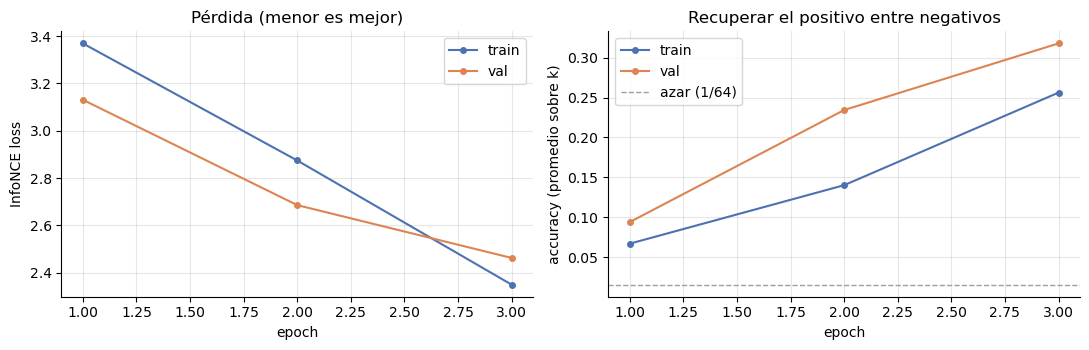

In [13]:
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                      "axes.grid": True, "grid.alpha": 0.3})

epochs = range(1, len(history["train_loss"]) + 1)
chance_acc = 1 / BATCH_SIZE

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(epochs, history["train_loss"], color="#4c72b0", marker="o", ms=4, label="train")
axes[0].plot(epochs, history["val_loss"], color="#dd8452", marker="o", ms=4, label="val")
axes[0].set(xlabel="epoch", ylabel="InfoNCE loss", title="Pérdida (menor es mejor)")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], color="#4c72b0", marker="o", ms=4, label="train")
axes[1].plot(epochs, history["val_acc"], color="#dd8452", marker="o", ms=4, label="val")
axes[1].axhline(chance_acc, color="#9e9e9e", ls="--", lw=1, label=f"azar (1/{BATCH_SIZE})")
axes[1].set(xlabel="epoch", ylabel="accuracy (promedio sobre k)", title="Recuperar el positivo entre negativos")
axes[1].legend()

fig.tight_layout()

## 4.5 Guardar el encoder entrenado

Guardamos los pesos de `model_real` (que incluye `Encoder` + `AutoRegressive` + `Predictor`) junto con
`cfg_real`, para poder reutilizarlos sin reentrenar. El siguiente paso natural es congelar
`Encoder` + `AutoRegressive` y entrenar un *linear probe* sobre `c_t` para las 7 clases de actividad
(`Labels/`) — la forma estándar de evaluar representaciones aprendidas con CPC (Haresamudram et al., 2020,
Sección 4). Para ese paso sí habrá que excluir los 2 archivos con anotaciones inconsistentes identificados
en la sección 5 del EDA.

In [14]:
CKPT_DIR = Path.cwd() / "_checkpoints"
CKPT_DIR.mkdir(exist_ok=True)
CKPT_PATH = CKPT_DIR / "cpc_emg.pt"

torch.save({
    "model_state_dict": model_real.state_dict(),
    "cfg": cfg_real,
    "history": history,
    "target_fs": TARGET_FS,
    "window_len": WINDOW_LEN,
}, CKPT_PATH)

print(f"Checkpoint guardado en {CKPT_PATH}")

Checkpoint guardado en /Users/yutsilflores/Documents/GitHub/human-activity-recognition/notebooks/_checkpoints/cpc_emg.pt
